# Сравнение трёх моделей: Random Forest, Extra Trees и Hist Gradient Boosting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

In [2]:
comparison_data = {
    'Модель': ['Random Forest', 'Extra Trees', 'Hist Gradient Boosting'],
    'Средний R²': [0.7770, 0.7646, 0.7843],
    'Средний MSE': [0.0018, 0.0019, 0.0020],
    'Средний RMSE': [0.0372, 0.0382, 0.0380],
    'Средний MAE': [0.0145, 0.0151, 0.0147],
    'Std R²': [0.1196, 0.1274, 0.0965],
    'Время обучения (сек)': [63.66, 25.62, 33.02]
}

df = pd.DataFrame(comparison_data)

print("=" * 80)
print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА МОДЕЛЕЙ")
print("=" * 80)
print(df.to_string(index=False))
print()

# Лучшая модель по R²
best_r2_idx = df['Средний R²'].idxmax()
print(f"Лучшая модель по R²: {df.loc[best_r2_idx, 'Модель']} (R² = {df.loc[best_r2_idx, 'Средний R²']:.4f})")

# Лучшая модель по MSE
best_mse_idx = df['Средний MSE'].idxmin()
print(f"Лучшая модель по MSE: {df.loc[best_mse_idx, 'Модель']} (MSE = {df.loc[best_mse_idx, 'Средний MSE']:.4f})")

# Самая стабильная модель (наименьший std R²)
best_stable_idx = df['Std R²'].idxmin()
print(f"Самая стабильная модель: {df.loc[best_stable_idx, 'Модель']} (Std R² = {df.loc[best_stable_idx, 'Std R²']:.4f})")

СРАВНИТЕЛЬНАЯ ТАБЛИЦА МОДЕЛЕЙ
                Модель  Средний R²  Средний MSE  Средний RMSE  Средний MAE  Std R²  Время обучения (сек)
         Random Forest      0.7770       0.0018        0.0372       0.0145  0.1196                 63.66
           Extra Trees      0.7646       0.0019        0.0382       0.0151  0.1274                 25.62
Hist Gradient Boosting      0.7843       0.0020        0.0380       0.0147  0.0965                 33.02

Лучшая модель по R²: Hist Gradient Boosting (R² = 0.7843)
Лучшая модель по MSE: Random Forest (MSE = 0.0018)
Самая стабильная модель: Hist Gradient Boosting (Std R² = 0.0965)


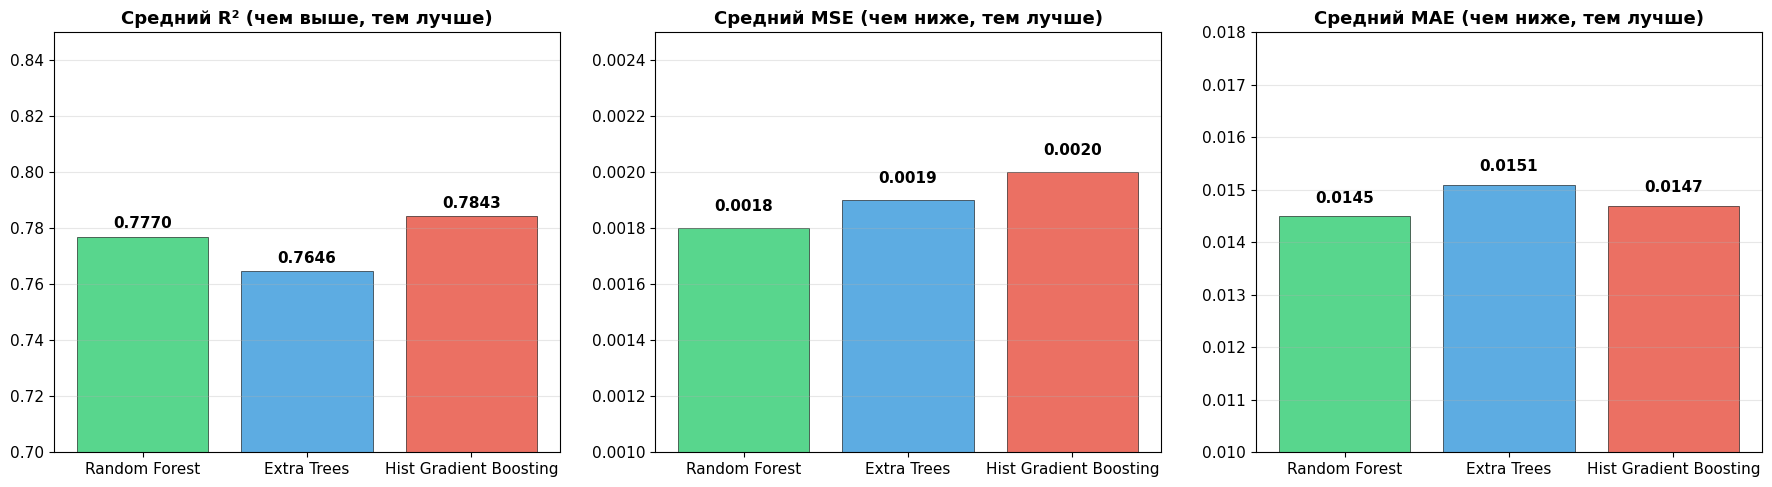

In [3]:
# Визуализация: сравнение R², MSE и MAE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = df['Модель']
colors = ['#2ecc71', '#3498db', '#e74c3c']

# R²
bars1 = axes[0].bar(models, df['Средний R²'], color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
axes[0].set_title('Средний R² (чем выше, тем лучше)', fontsize=13, fontweight='bold')
axes[0].set_ylim(0.7, 0.85)
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, df['Средний R²']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# MSE
bars2 = axes[1].bar(models, df['Средний MSE'], color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
axes[1].set_title('Средний MSE (чем ниже, тем лучше)', fontsize=13, fontweight='bold')
axes[1].set_ylim(0.001, 0.0025)
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, df['Средний MSE']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.00005,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# MAE
bars3 = axes[2].bar(models, df['Средний MAE'], color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
axes[2].set_title('Средний MAE (чем ниже, тем лучше)', fontsize=13, fontweight='bold')
axes[2].set_ylim(0.01, 0.018)
axes[2].grid(axis='y', alpha=0.3)
for bar, val in zip(bars3, df['Средний MAE']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/model_comparison_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

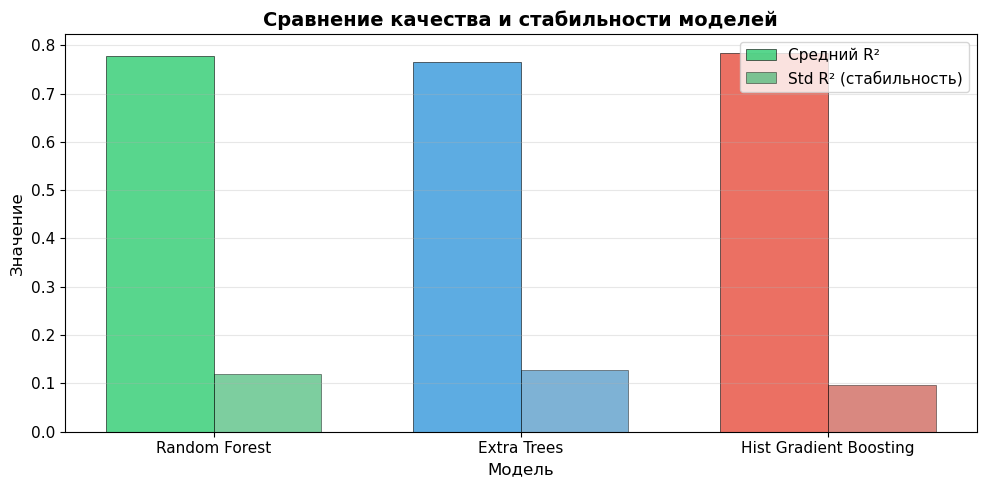

In [4]:
# Сравнение стабильности моделей (стандартное отклонение R²)
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(models))
width = 0.35

bars_mean = ax.bar(x - width/2, df['Средний R²'], width, label='Средний R²',
                   color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
bars_std = ax.bar(x + width/2, df['Std R²'], width, label='Std R² (стабильность)',
                  color=['#27ae60', '#2980b9', '#c0392b'], alpha=0.6, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Модель', fontsize=12)
ax.set_ylabel('Значение', fontsize=12)
ax.set_title('Сравнение качества и стабильности моделей', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/model_stability_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

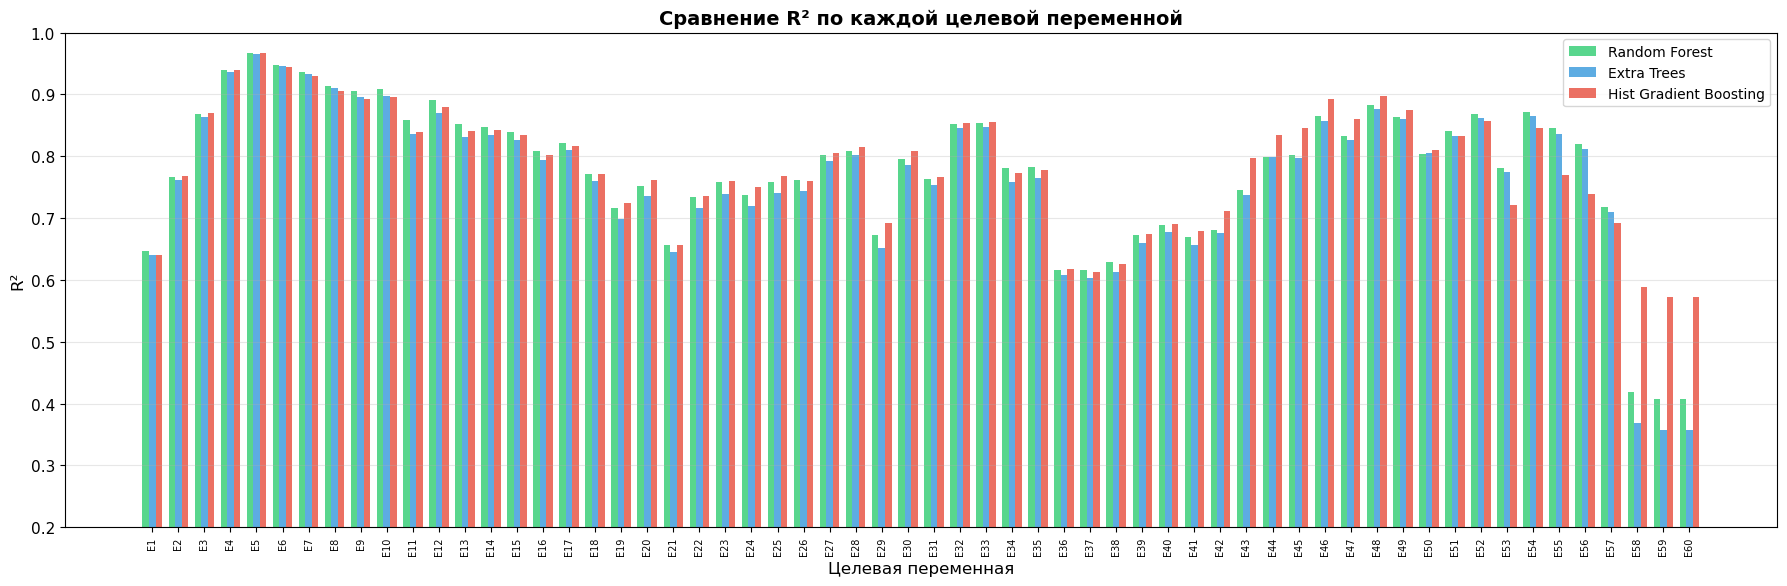

In [5]:
# Детальное сравнение по каждой целевой переменной (R²)
# Данные по R² для каждой цели из трёх моделей
target_r2_data = {
    'Цель': [f'E{i+1}_norm' for i in range(60)],
    'Random Forest': [
        0.6462, 0.7671, 0.8679, 0.9394, 0.9667, 0.9477, 0.9360, 0.9133, 0.9051, 0.9089,
        0.8579, 0.8914, 0.8527, 0.8480, 0.8387, 0.8088, 0.8210, 0.7719, 0.7166, 0.7523,
        0.6572, 0.7336, 0.7583, 0.7374, 0.7576, 0.7623, 0.8015, 0.8082, 0.6723, 0.7961,
        0.7639, 0.8520, 0.8534, 0.7810, 0.7824, 0.6163, 0.6163, 0.6285, 0.6727, 0.6888,
        0.6694, 0.6806, 0.7460, 0.7992, 0.8018, 0.8657, 0.8334, 0.8820, 0.8638, 0.8028,
        0.8411, 0.8683, 0.7805, 0.8720, 0.8462, 0.8198, 0.7177, 0.4194, 0.4068, 0.4068
    ],
    'Extra Trees': [
        0.6402, 0.7612, 0.8633, 0.9366, 0.9651, 0.9455, 0.9332, 0.9106, 0.8964, 0.8968,
        0.8359, 0.8704, 0.8306, 0.8349, 0.8257, 0.7940, 0.8100, 0.7594, 0.6982, 0.7361,
        0.6447, 0.7168, 0.7386, 0.7202, 0.7405, 0.7445, 0.7925, 0.8013, 0.6513, 0.7860,
        0.7529, 0.8454, 0.8465, 0.7587, 0.7653, 0.6087, 0.6027, 0.6125, 0.6604, 0.6769,
        0.6564, 0.6762, 0.7366, 0.7992, 0.7971, 0.8564, 0.8262, 0.8771, 0.8594, 0.8056,
        0.8332, 0.8621, 0.7749, 0.8647, 0.8352, 0.8120, 0.7098, 0.3679, 0.3569, 0.3569
    ],
    'Hist Gradient Boosting': [
        0.6400, 0.7673, 0.8697, 0.9389, 0.9661, 0.9436, 0.9301, 0.9051, 0.8927, 0.8961,
        0.8395, 0.8791, 0.8408, 0.8426, 0.8340, 0.8022, 0.8170, 0.7707, 0.7251, 0.7616,
        0.6565, 0.7355, 0.7600, 0.7495, 0.7686, 0.7607, 0.8047, 0.8146, 0.6925, 0.8082,
        0.7665, 0.8531, 0.8550, 0.7730, 0.7780, 0.6180, 0.6133, 0.6262, 0.6745, 0.6905,
        0.6789, 0.7113, 0.7974, 0.8338, 0.8460, 0.8929, 0.8608, 0.8981, 0.8740, 0.8103,
        0.8325, 0.8567, 0.7215, 0.8459, 0.7701, 0.7395, 0.6914, 0.5887, 0.5725, 0.5725
    ]
}

df_r2 = pd.DataFrame(target_r2_data)

# График R² по каждой целевой переменной
fig, ax = plt.subplots(figsize=(18, 6))

x = np.arange(60)
width = 0.25

ax.bar(x - width, df_r2['Random Forest'], width, label='Random Forest', color='#2ecc71', alpha=0.8)
ax.bar(x, df_r2['Extra Trees'], width, label='Extra Trees', color='#3498db', alpha=0.8)
ax.bar(x + width, df_r2['Hist Gradient Boosting'], width, label='Hist Gradient Boosting', color='#e74c3c', alpha=0.8)

ax.set_xlabel('Целевая переменная', fontsize=12)
ax.set_ylabel('R²', fontsize=12)
ax.set_title('Сравнение R² по каждой целевой переменной', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'E{i+1}' for i in range(60)], rotation=90, fontsize=7)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0.2, 1.0)

plt.tight_layout()
plt.savefig('../results/r2_per_target.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
print("=" * 80)
print("ИТОГОВЫЕ ВЫВОДЫ")
print("=" * 80)

print("""
1. ПО ОБЩЕМУ КАЧЕСТВУ (R²):
   - Лучшая модель: Hist Gradient Boosting (R² = 0.7843)
   - На втором месте: Random Forest (R² = 0.7770)
   - На третьем месте: Extra Trees (R² = 0.7646)
   
   Разница между моделями незначительная (~0.02), что говорит о том,
   что все три модели показывают сопоставимое качество.

2. ПО СТАБИЛЬНОСТИ (Std R²):
   - Самая стабильная: Hist Gradient Boosting (Std = 0.0965)
   - На втором месте: Random Forest (Std = 0.1196)
   - На третьем месте: Extra Trees (Std = 0.1274)
   
   Hist Gradient Boosting показывает наиболее стабильные предсказания
   по всем 60 целевым переменным.

3. ПО КАЧЕСТВУ ДЛЯ "ТРУДНЫХ" ЦЕЛЕЙ (E58-E60):
   - Hist Gradient Boosting значительно лучше справляется с трудными целями:
     * E58: HGB R²=0.5887 vs RF R²=0.4194 vs ET R²=0.3679
     * E59-E60: HGB R²=0.5725 vs RF R²=0.4068 vs ET R²=0.3569
   
   Это ключевое преимущество Hist Gradient Boosting.

4. ПО СКОРОСТИ ОБУЧЕНИЯ:
   - Extra Trees: ~26 секунд (самая быстрая)
   - Hist Gradient Boosting: ~33 секунды
   - Random Forest: ~64 секунды (самая медленная)

5. ИТОГОВАЯ РЕКОМЕНДАЦИЯ:
   Hist Gradient Boosting — лучшая модель для данной задачи, так как:
   - Показывает лучший R² (0.7843)
   - Наиболее стабильна (Std R² = 0.0965)
   - Значительно лучше справляется с трудными целевыми переменными
   - Незначительно уступает в скорости обучения (~10 секунд разницы)
""")

ИТОГОВЫЕ ВЫВОДЫ

1. ПО ОБЩЕМУ КАЧЕСТВУ (R²):
   - Лучшая модель: Hist Gradient Boosting (R² = 0.7843)
   - На втором месте: Random Forest (R² = 0.7770)
   - На третьем месте: Extra Trees (R² = 0.7646)

   Разница между моделями незначительная (~0.02), что говорит о том,
   что все три модели показывают сопоставимое качество.

2. ПО СТАБИЛЬНОСТИ (Std R²):
   - Самая стабильная: Hist Gradient Boosting (Std = 0.0965)
   - На втором месте: Random Forest (Std = 0.1196)
   - На третьем месте: Extra Trees (Std = 0.1274)

   Hist Gradient Boosting показывает наиболее стабильные предсказания
   по всем 60 целевым переменным.

3. ПО КАЧЕСТВУ ДЛЯ "ТРУДНЫХ" ЦЕЛЕЙ (E58-E60):
   - Hist Gradient Boosting значительно лучше справляется с трудными целями:
     * E58: HGB R²=0.5887 vs RF R²=0.4194 vs ET R²=0.3679
     * E59-E60: HGB R²=0.5725 vs RF R²=0.4068 vs ET R²=0.3569

   Это ключевое преимущество Hist Gradient Boosting.

4. ПО СКОРОСТИ ОБУЧЕНИЯ:
   - Extra Trees: ~26 секунд (самая быстрая)
   - Hi

In [7]:
final_summary = {
    'Критерий': ['Средний R²', 'Средний MSE', 'Средний MAE', 'Стабильность (Std R²)', 'Скорость обучения'],
    'Random Forest': ['0.7770 (2-е место)', '0.0018 (1-е место)', '0.0145 (1-е место)', '0.1196 (2-е место)', '~64 сек (3-е место)'],
    'Extra Trees': ['0.7646 (3-е место)', '0.0019 (2-е место)', '0.0151 (3-е место)', '0.1274 (3-е место)', '~26 сек (1-е место)'],
    'Hist Gradient Boosting': ['0.7843 (1-е место)', '0.0020 (3-е место)', '0.0147 (2-е место)', '0.0965 (1-е место)', '~33 сек (2-е место)']
}

df_final = pd.DataFrame(final_summary)
print(df_final.to_string(index=False))

             Критерий       Random Forest         Extra Trees Hist Gradient Boosting
           Средний R²  0.7770 (2-е место)  0.7646 (3-е место)     0.7843 (1-е место)
          Средний MSE  0.0018 (1-е место)  0.0019 (2-е место)     0.0020 (3-е место)
          Средний MAE  0.0145 (1-е место)  0.0151 (3-е место)     0.0147 (2-е место)
Стабильность (Std R²)  0.1196 (2-е место)  0.1274 (3-е место)     0.0965 (1-е место)
    Скорость обучения ~64 сек (3-е место) ~26 сек (1-е место)    ~33 сек (2-е место)
